# Running Simulations: From a Pulse to a Saved BOLD Dataset

This notebook walks through the **forward simulation pipeline** in this repo, end to end:

1. A **pulse** of neural activity is generated at a source voxel.
2. That pulse **diffuses across a spatial grid and between cortical layers** (the "cortex simulator").
3. The resulting neural activity drives the **Balloon/Heinzle haemodynamic model**, producing latent
   physiological states (`s, f, v, q, v*, q*`) and finally a **BOLD signal**.
4. `scripts/run_sim.py` wraps all of this into a Hydra-configured CLI that generates thousands of such
   samples and writes them to a single HDF5 file.
5. We load that HDF5 file back and inspect it the way training code does.

This notebook only covers *simulation* (generating synthetic ground-truth data). What happens to that
data during training/inversion is covered in `02_heinzlenet_model.ipynb` (the network architecture) and
`lightning_framework.md` (the training loop and losses; see also the deeper `heinzlenet.md` and
`training.md` docs already in this folder).

Every class used below is real repo code. We're just calling `src/mich/data/*.py` directly with small, fast-to-run settings.

In [108]:
import json
import subprocess
import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
assert (REPO_ROOT / "src" / "mich").exists(), f"Expected repo root, got {REPO_ROOT}"

np.random.seed(0)
%matplotlib inline

## 1. Pulses: shaping a single voxel's neural drive over time

The lowest-level building block is a **pulse shape** which is a function of time describing how strongly one
"source" voxel is driven. These live in `src/mich/data/signals.py`. Two pulse shapes are actually used by
the simulator (`TriangularPulse`, `SincPulse`, `AlphaPulse` are marked `@deprecated` and
`scripts/run_sim.py` will reject them):

- **`RectPulse(amplitude, t_onset, width)`** is a boxcar: on at `t_onset`, off at `t_onset + width`.
- **`ExpDecayPulse(amplitude, t_onset, decay_rate)`** switches on at `t_onset`, then decays exponentially.

A simulated "source" is rarely just one pulse. It's a **train** of pulses over the recording, handled by
the `Pulse` dataclass, which sums however many peaks you give it onto a shared time grid.

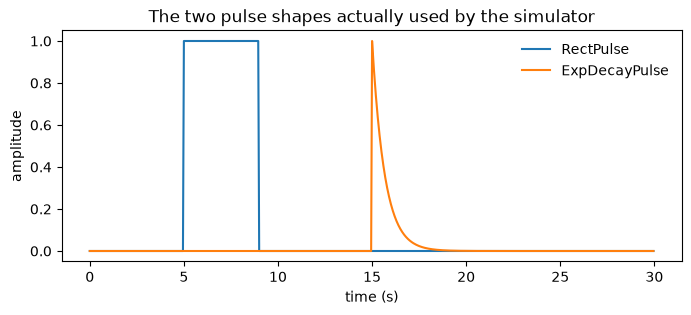

In [109]:
from mich.data.signals import ExpDecayPulse, Pulse, RectPulse

t = np.arange(0, 30, 0.05)

rect = RectPulse(amplitude=1.0, t_onset=5.0, width=4.0)
decay = ExpDecayPulse(amplitude=1.0, t_onset=15.0, decay_rate=1.5)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t, rect.generate(t), label="RectPulse")
ax.plot(t, decay.generate(t), label="ExpDecayPulse")
ax.set_xlabel("time (s)")
ax.set_ylabel("amplitude")
ax.legend(frameon=False, loc="upper right")
ax.set_title("The two pulse shapes actually used by the simulator")
plt.show()

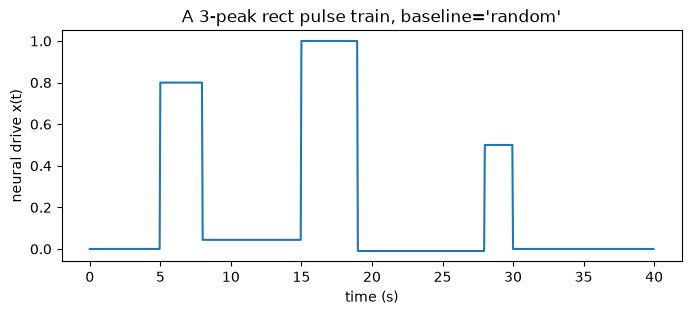

In [110]:
# A `Pulse` is a *train* of same-type peaks, each described by its own parameter list
# (for "rect": [amplitude, t_onset, width]). This is exactly what run_sim.py builds per
# source, one random pulse train per active voxel (see `_draw_pulse_signal` in run_sim.py).
rng = np.random.default_rng(42)

pulse_train = Pulse(
    pulse_type="rect",
    peaks=[
        [0.8, 5.0, 3.0],
        [1.0, 15.0, 4.0],
        [0.5, 28.0, 2.0],
    ],
    duration=40.0,
    dt=0.05,
    baseline="random",  # adds a small random offset in the zero gaps between pulses
    rng=rng,
)
t_train, signal_train = pulse_train.generate()

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_train, signal_train)
ax.set_xlabel("time (s)")
ax.set_ylabel("neural drive x(t)")
ax.set_title("A 3-peak rect pulse train, baseline='random'")
plt.show()

## 2. Cortex simulation: diffusing neural activity across space and layers

A pulse train only describes what happens *at the source voxel*. The **`LayeredDiffusionSimulator`**
(`src/mich/data/neuronal.py`) takes one or more sources and simulates how that activity spreads:

- **spatially**, via a discrete 2D Laplacian (in-plane diffusion, `diffusion_coefficient_intra`),
- **between cortical layers**, via a nearest-neighbour coupling term (`diffusion_coefficient_inter`),
- with **exponential decay** back to baseline (`decay_rate`),
- integrated with forward-Euler substeps, whose count is auto-computed from a CFL-style stability bound
  (raises if `dt` is too large for the diffusion strength given).

Each timestep, the source voxel(s) are **pinned** to the pulse-train value at that step (re-pinned after
every substep, so decay doesn't erode the injected signal), and the rest of the grid evolves purely from
diffusion + decay.

In [111]:
from mich.data.neuronal import LayeredDiffusionSimulator, NeuralSimulatorParams
from mich.data.signals import Noise, Sources

grid_size = (10, 10)
num_layers = 2  # e.g. "deep" and "superficial"
steps = 60

sim_params = NeuralSimulatorParams(
    num_layers=num_layers,
    grid_size=grid_size,
    dt=1.0,
    dx=1.0,
    diffusion_coefficient_inter=0.0,
    diffusion_coefficient_intra=2.0,
    decay_rate=1.0,
)
simulator = LayeredDiffusionSimulator(sim_params)

# Build one source per layer using the pulse-train helper above.
sources = Sources()
for layer, onset in [(0, 5.0), (1, 8.0)]:
    peaks = [[0.9, onset, 4.0]]
    _, sig = Pulse(
        pulse_type="rect", peaks=peaks, duration=steps, dt=1.0, baseline="fixed"
    ).generate()
    sources.add_source(layer=layer, position=(8, 8), signal=sig)

history = simulator.simulate(
    sources=sources.get_sources(),
    steps=steps,
    snr_db=np.inf,  # np.inf -> no injected neural noise, for a clean first look
    noise=Noise(type="pink", domain="both"),
)
print("history shape (steps, num_layers, H, W):", history.shape)

history shape (steps, num_layers, H, W): (60, 2, 10, 10)


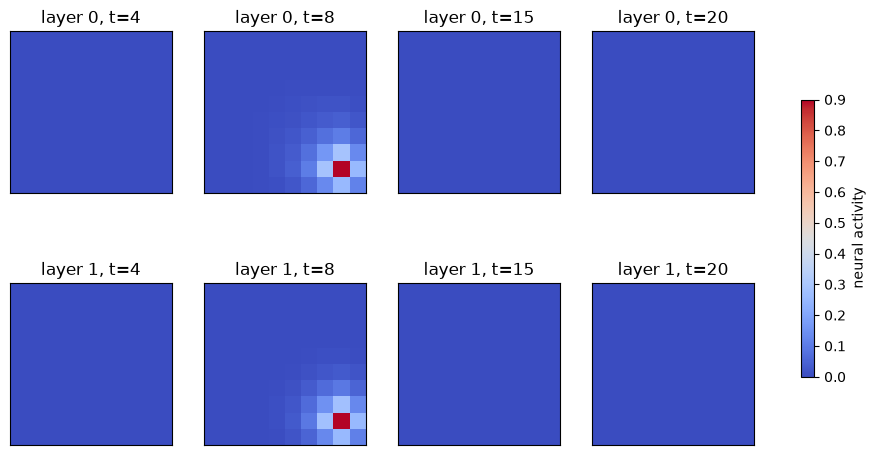

In [112]:
# Snapshot the spatial spread at a few timepoints, one row per layer.
snapshot_steps = [4, 8, 15, 20]
vmax = np.abs(history).max()
vmin = np.abs(history).min()

fig, axes = plt.subplots(
    num_layers, len(snapshot_steps), figsize=(3 * len(snapshot_steps), 3 * num_layers)
)
for layer in range(num_layers):
    for col, step in enumerate(snapshot_steps):
        ax = axes[layer, col]
        im = ax.imshow(history[step, layer], vmin=vmin, vmax=vmax, cmap="coolwarm")
        ax.set_title(f"layer {layer}, t={step}")
        ax.set_xticks([])
        ax.set_yticks([])
fig.colorbar(im, ax=axes, shrink=0.6, label="neural activity")
plt.show()

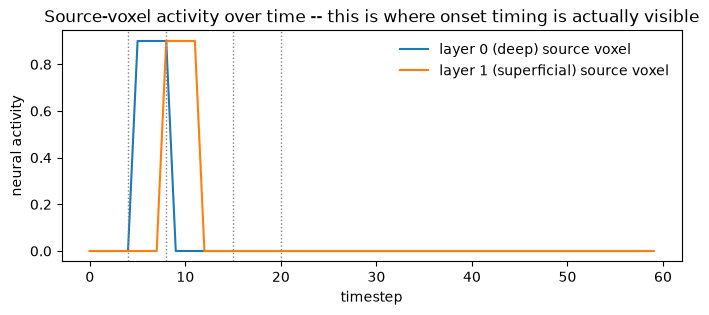

In [113]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(history[:, 0, 8, 8], label="layer 0 (deep) source voxel")
ax.plot(history[:, 1, 8, 8], label="layer 1 (superficial) source voxel")
for step in snapshot_steps:
    ax.axvline(step, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("timestep")
ax.set_ylabel("neural activity")
ax.set_title("Source-voxel activity over time -- this is where onset timing is actually visible")
ax.legend(frameon=False, loc="upper right")
plt.show()

The timecourse above is the clean way to see the two sources' different onset times (layer 0 at t=5, layer 1 at t=8) -- the vertical dotted lines mark the four snapshot columns plotted above.

The snapshot grid itself is best read as evidence of the **spatial blurring**: at t=8, both sources already show a smooth radial bump rather than a sharp single-pixel spike, because `diffusion_coefficient_intra=12.0` equilibrates a source's local neighbourhood within about one timestep -- faster than the 3-step gap between the two onsets, which is why the two layers' bumps look similar in magnitude at t=8 rather than one obviously smaller than the other. If you want the spatial spread itself to look more gradual across the snapshot columns, lower `diffusion_coefficient_intra` (e.g. to 2-3) and rerun.

## 3. From neural activity to BOLD: the Balloon/Heinzle forward model

The neural activity `x` computed above is not what a scanner measures. It drives a per-voxel
**haemodynamic state** (vasodilatory signal `s`, blood inflow `f`, blood volume `v`, deoxyhaemoglobin
content `q`, plus delayed drainage terms `v*`, `q*` if a layer drains from one below it) via the
Balloon-Windkessel ODEs in `src/mich/data/balloon.py`. The BOLD signal is then a fixed nonlinear readout
of `v` and `q`.

Key building blocks:

- **`HaemodynamicConstants`**: `kappa` (vasodilatory decay), `gamma` (autoregulation), `alpha` (Grubb's
  exponent), `E0` (resting oxygen extraction), `V0` (resting blood volume).
- **`CortexLayer`**: one cortical depth, holding its `tau` (transit time), its `HaemodynamicState`, and
  `lambda_d`/`drain_from` describing whether/how much it drains from the layer below it.
- **`simulate_cortex(layers, constants, x_inputs, dt=..., tau_d=..., order=...)`**: integrates the ODEs
  with RK4 for every layer simultaneously. `order` selects the Balloon-Windkessel approximation
  (`"exact"`, `"linear"`, or `"quadratic"`, see `config/simulation/{exact,linear,quadratic}.yaml`).
- **`get_bold_from_state(state, acq, c, layer_depth=..., params=...)`**: applies the BOLD readout
  equation, then optionally a per-layer Gaussian point-spread function (PSF) and additive noise.

We'll build a 2-layer cortex (superficial drains from deep) directly from the neural activity we just
simulated.

In [114]:
from mich.data.balloon import (
    AcquisitionConstants,
    BoldPostProcessingConfig,
    CortexLayer,
    HaemodynamicConstants,
    HaemodynamicState,
    NoiseModel,
    PointSpreadFunction,
    get_bold_from_state,
    simulate_cortex,
)

haemo = HaemodynamicConstants(alpha=0.32, E0=0.34, V0=0.05, kappa=1.92, gamma=0.41)
# k1/k2/k3 as derived in scripts/run_sim.py:_derive_acquisition for a 7T acquisition
acq = AcquisitionConstants(
    k1=4.3 * 28.625 * haemo.E0 * 0.25, k2=1e-32 * 340 * haemo.E0 * 0.25, k3=1.0 - 1e-32
)


def make_layer(depth, tau, lambda_d, drain_from, grid_size):
    state = HaemodynamicState(
        x=np.zeros(grid_size),
        s=np.zeros(grid_size),
        f=np.ones(grid_size),
        v=np.ones(grid_size),
        q=np.ones(grid_size),
        v_star=np.zeros(grid_size),
        q_star=np.zeros(grid_size),
    )
    return CortexLayer(depth=depth, tau=tau, state=state, lambda_d=lambda_d, drain_from=drain_from)


layer_tau = 2.66
deep = make_layer(depth=0, tau=layer_tau, lambda_d=0.0, drain_from=None, grid_size=grid_size)
superficial = make_layer(depth=1, tau=layer_tau, lambda_d=1.0, drain_from=deep, grid_size=grid_size)

# haemo_dt is typically finer than the neural dt=1.0s -- upsample x by repeating each
# neural step, exactly as scripts/run_sim.py does before calling simulate_cortex.
haemo_dt = 0.05
upsample = int(round(sim_params.dt / haemo_dt))
x_inputs = [np.repeat(history[:, layer], upsample, axis=0) for layer in range(num_layers)]

cortex_states = simulate_cortex(
    layers=[deep, superficial],
    constants=haemo,
    x_inputs=x_inputs,
    dt=haemo_dt,
    tau_d=1.0,
    order="exact",
)
print("cortex_states keys (one per layer depth):", list(cortex_states.keys()))
print("per-layer state keys:", list(cortex_states[0].keys()))
print("shape of each timecourse:", cortex_states[0]["v"].shape, "(upsampled T, H, W)")

cortex_states keys (one per layer depth): [0, 1]
per-layer state keys: ['x', 's', 'f', 'v', 'q', 'v*', 'q*']
shape of each timecourse: (1200, 10, 10) (upsampled T, H, W)


In [115]:
# PSF + noise: deep layers get a narrower PSF, superficial layers a wider one, matching
# config/simulation/base.yaml's bold.psf_fwhm_mm=[0.83, 1.78] convention.
psf_by_layer = {0: PointSpreadFunction(fwhm=1.0), 1: PointSpreadFunction(fwhm=2.0)}
noise_7T = NoiseModel.preset("7T", V=8.0, TR=2.0)

bold_by_layer = {}
for layer in (0, 1):
    params = BoldPostProcessingConfig(
        layer_psf=psf_by_layer,
        noise=Noise(type="white", seed=0),
        snr_db=0.5,  # dB; np.inf disables noise entirely
    )
    bold_by_layer[layer] = get_bold_from_state(
        cortex_states[layer], acq, haemo, layer_depth=layer, params=params
    )

print("BOLD shape per layer:", bold_by_layer[0].shape)

BOLD shape per layer: (1200, 10, 10)


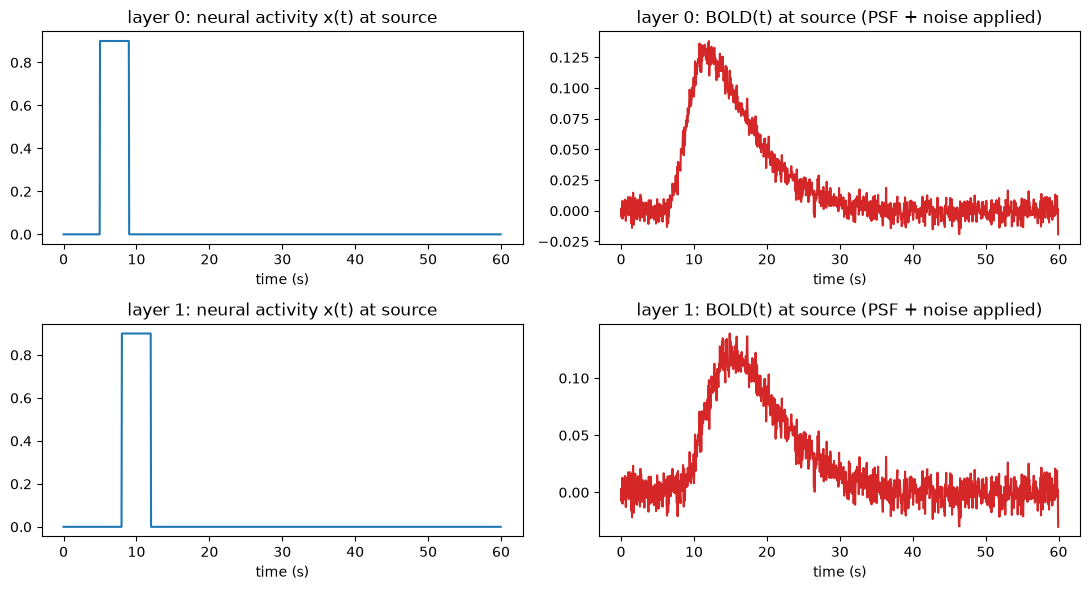

In [116]:
# Compare neural drive x vs the resulting BOLD at the source voxel, for both layers.
source_pos = (8, 8)
fig, axes = plt.subplots(num_layers, 2, figsize=(11, 3 * num_layers), squeeze=False)
t_haemo = np.arange(cortex_states[0]["v"].shape[0]) * haemo_dt

for layer in range(num_layers):
    x_full = np.repeat(history[:, layer, source_pos[0], source_pos[1]], upsample)
    axes[layer, 0].plot(t_haemo, x_full)
    axes[layer, 0].set_title(f"layer {layer}: neural activity x(t) at source")
    axes[layer, 0].set_xlabel("time (s)")

    axes[layer, 1].plot(
        t_haemo, bold_by_layer[layer][:, source_pos[0], source_pos[1]], color="tab:red"
    )
    axes[layer, 1].set_title(f"layer {layer}: BOLD(t) at source (PSF + noise applied)")
    axes[layer, 1].set_xlabel("time (s)")
plt.tight_layout()
plt.show()

The line plots above show the source voxel only. The animation below shows the full spatial grid over time for both layers side by side: superficial (layer 1) on top, deep (layer 0) on the bottom, neural activity on the left and BOLD on the right, so the spatial spread and the neural-to-BOLD delay are both visible at once.


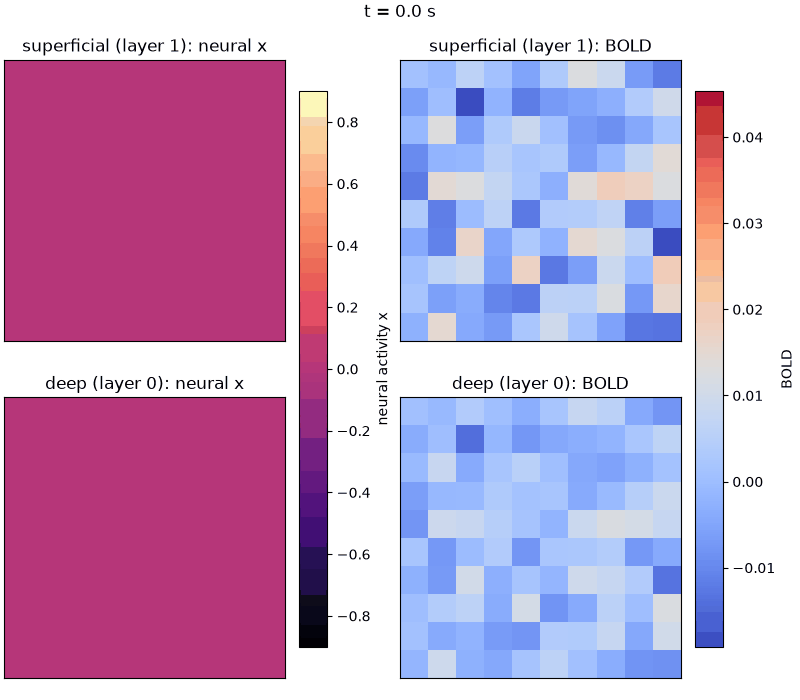

In [117]:
import base64
import tempfile

from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation

# One frame per original neural timestep (60 frames), rather than every haemo_dt substep.
frame_idx = np.arange(0, cortex_states[0]["x"].shape[0], upsample)
rows = [(1, "superficial"), (0, "deep")]  # top row first

neural_frames = {depth: cortex_states[depth]["x"][frame_idx] for depth, _ in rows}
bold_frames = {depth: bold_by_layer[depth][frame_idx] for depth, _ in rows}

neural_vmax = max(np.abs(neural_frames[depth]).max() for depth, _ in rows)
bold_all = np.concatenate([bold_frames[depth] for depth, _ in rows])
bold_vmin, bold_vmax = np.quantile(bold_all, [0.01, 0.99])

fig, axes = plt.subplots(2, 2, figsize=(8, 7), constrained_layout=True)
panels = []
for row, (depth, name) in enumerate(rows):
    im_neural = axes[row, 0].imshow(
        neural_frames[depth][0], vmin=-neural_vmax, vmax=neural_vmax, cmap="magma"
    )
    axes[row, 0].set_title(f"{name} (layer {depth}): neural x")
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])

    im_bold = axes[row, 1].imshow(
        bold_frames[depth][0], vmin=bold_vmin, vmax=bold_vmax, cmap="coolwarm"
    )
    axes[row, 1].set_title(f"{name} (layer {depth}): BOLD")
    axes[row, 1].set_xticks([])
    axes[row, 1].set_yticks([])
    panels.append((im_neural, im_bold))

# One colorbar per column, shared across both layer rows since both rows already use the
# same vmin/vmax. This is what lets you compare magnitude across layers, not just within one.
fig.colorbar(panels[0][0], ax=[axes[0, 0], axes[1, 0]], shrink=0.85, label="neural activity x")
fig.colorbar(panels[0][1], ax=[axes[0, 1], axes[1, 1]], shrink=0.85, label="BOLD")

time_title = fig.suptitle("")
16


def update(frame):
    for row, (depth, _name) in enumerate(rows):
        panels[row][0].set_data(neural_frames[depth][frame])
        panels[row][1].set_data(bold_frames[depth][frame])
    time_title.set_text(f"t = {frame_idx[frame] * haemo_dt:.1f} s")
    return [im for pair in panels for im in pair]


anim = FuncAnimation(fig, update, frames=len(frame_idx), interval=120, blit=False)
plt.close(fig)  # suppress the static leftover figure, only the animation below is wanted

gif_path = Path(tempfile.gettempdir()) / "mich_grid_timecourse_demo.gif"
anim.save(gif_path, writer="pillow", fps=10)
with open(gif_path, "rb") as f:
    encoded = base64.b64encode(f.read()).decode("ascii")
gif_path.unlink()

display(HTML(f'<img src="data:image/gif;base64,{encoded}">'))

Note the BOLD response is delayed and smoothed relative to the neural drive. That is the haemodynamic
response function emerging naturally from the ODE integration, not a hand-coded convolution. This is
exactly the relationship `HeinzleNet` (see `02_heinzlenet_model.ipynb`) has to invert: given only the
right-hand BOLD trace, recover the left-hand neural activity (and the latent `s, f, v, q` in between).

## 4. Generating full datasets: `scripts/run_sim.py` + Hydra configs

Everything above was assembled by hand for one sample. In practice, datasets are generated with
**`scripts/run_sim.py`**, a [Hydra](https://hydra.cc/) CLI that:

1. draws a **random pulse train** per active source (`_draw_pulse_signal`),
2. places sources on the grid according to `simulation.source_placement`,
3. runs the neural diffusion simulator,
4. builds the `CortexLayer` chain and runs `simulate_cortex` + `get_bold_from_state`,
5. writes every sample incrementally into one HDF5 file (optionally in parallel across `workers`
   processes).

All physics/geometry parameters live in `config/simulation/*.yaml`. `base.yaml` is a complete, standalone
config (3-layer cortex with drainage, 10×10 grid); every other file composes `defaults: [base, _self_]`
and overrides only what differs:

| Config | What it changes vs. `base.yaml` |
|---|---|
| `single_layer_single_source.yaml` | 1 layer, exactly 1 source |
| `single_layer_multi_source.yaml` | 1 layer, 2-4 sources |
| `three_layer_single_source_single_active.yaml` | 3 layers, only 1 active per sim, 1 source |
| `three_layer_multi_source_single_active.yaml` | 3 layers, only 1 active per sim, 2-4 sources |
| `three_layer_multi_source_multi_active.yaml` | 3 layers, 2-3 active per sim, 2-4 sources each |
| `three_layer_single_source_shared_position*.yaml` | sources share one (x,y) cortical column (plus a shared pulse waveform for the `_shared_pulse` variant) |
| `exact.yaml` / `linear.yaml` / `quadratic.yaml` | select `simulation.order`, the Balloon-Windkessel approximation (`linear` also shrinks to 1 layer, no drainage; it's the fast default for `run_sim.py` when no `--config-name` is given) |

Any key can be overridden from the CLI with dot syntax, e.g.:
```bash
python scripts/run_sim.py --config-name=single_layer_single_source \
    num_simulations=3000 simulation.BOLD_SNR=10.0 output_path=data/my_run.h5
```
and swept with Hydra multirun (`-m`), e.g. the sweep files under `data/grid/` were generated with:
```bash
python scripts/run_sim.py -m --config-name=three_layer_multi_source_single_active \
    haemodynamic.kappa=1.768,1.840,1.916,1.994,2.075 \
    simulation.layer_tau=2.416,2.537,2.664,2.798,2.939 \
    num_simulations=50 workers=5
```

Let's actually run it: a tiny 5-sample dataset with the `single_layer_single_source` scenario, so this
executes quickly.

In [118]:
demo_output = REPO_ROOT / "data" / "demo_notebook_run.h5"

result = subprocess.run(
    [
        sys.executable,
        str(REPO_ROOT / "scripts" / "run_sim.py"),
        "--config-name=single_layer_single_source",
        "num_simulations=5",
        "seed=0",
        "workers=1",
        f"output_path={demo_output}",
    ],
    cwd=REPO_ROOT,
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
result.check_returncode()

  [1/5] seed=0
  [2/5] seed=1
  [3/5] seed=2
  [4/5] seed=3
  [5/5] seed=4
Saved 5 simulation(s) -> /media/RCPNAS/Data2/sengupta/inversion/mich/data/demo_notebook_run.h5



## 5. Loading saved simulation data

Every `.h5` file `run_sim.py` writes shares the same schema:

```
/layer_{0..num_layers-1}/
    bold, x                          (num_sims, T, H, W)       float16   -- full temporal resolution
    s, f, v, q, v_star, q_star       (num_sims, T_latent, H, W) float16   -- T_latent = T // latent_downsample
/meta/
    .attrs["config"]                 JSON string: the fully-resolved simulation config used
    num_sources                      (num_sims,)               int32
    seed                             (num_sims,)               int64
    sources/layer                    (num_sims, max_sources)          int32, -1 = unused slot
    sources/position                (num_sims, max_sources, 2)       int32, -1 = unused slot
    sources/num_pulses               (num_sims, max_sources)          int32
    sources/pulses                   (num_sims, max_sources, max_pulses, n_pulse_params) float64
```

`max_sources = num_layers * max(sources_per_layer)`; unused source slots are padded with `-1`/`NaN`. This
is the exact pattern `SyntheticH5Dataset` (`src/mich/data/synthetic.py`, used for training) reads from,
and the pattern used in `notebooks/datatest.ipynb`.

In [119]:
with h5py.File(demo_output, "r") as f:
    layer_keys = sorted(k for k in f.keys() if k.startswith("layer"))
    print("layers:", layer_keys)
    print("datasets per layer:", list(f[layer_keys[0]].keys()))

    bold = np.stack([f[layer]["bold"][:] for layer in layer_keys], axis=1)  # (N, L, T, H, W)
    x = np.stack([f[layer]["x"][:] for layer in layer_keys], axis=1)
    s = np.stack([f[layer]["s"][:] for layer in layer_keys], axis=1)
    q = np.stack([f[layer]["q"][:] for layer in layer_keys], axis=1)

    source_layer = f["meta"]["sources"]["layer"][:]  # (N, max_sources), -1 = unused
    source_position = f["meta"]["sources"]["position"][:]  # (N, max_sources, 2)
    sim_config = json.loads(f["meta"].attrs["config"])

print("bold shape (N, L, T, H, W):", bold.shape, bold.dtype)
print("source_layer[:3]:", source_layer[:3].ravel())
print("source_position[:3]:", source_position[:3].reshape(3, -1))
print(
    "simulated with order:",
    sim_config["simulation"]["order"],
    "| BOLD_SNR:",
    sim_config["simulation"]["BOLD_SNR"],
)

layers: ['layer_0']
datasets per layer: ['bold', 'f', 'q', 'q_star', 's', 'v', 'v_star', 'x']
bold shape (N, L, T, H, W): (5, 1, 100, 10, 10) float16
source_layer[:3]: [0 0 0]
source_position[:3]: [[8 6]
 [4 5]
 [8 2]]
simulated with order: exact | BOLD_SNR: 20.0


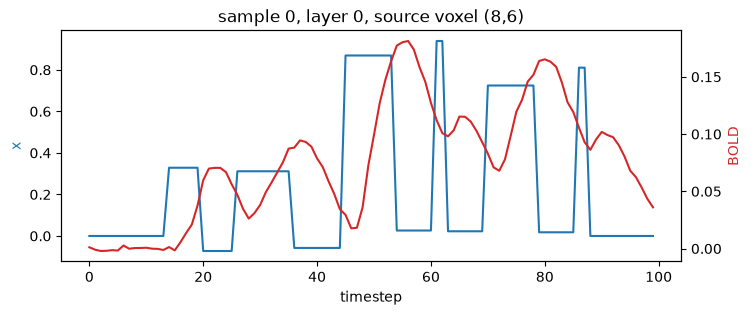

In [120]:
# Plot BOLD vs neural activity at the (known) source voxel for one sample.
sample_idx = 0
layer = int(source_layer[sample_idx, 0])
i, j = source_position[sample_idx, 0]

fig, ax = plt.subplots(figsize=(8, 3))
ax2 = ax.twinx()
ax.plot(x[sample_idx, layer, :, i, j], color="tab:blue", label="neural x(t)")
ax2.plot(bold[sample_idx, layer, :, i, j], color="tab:red", label="BOLD(t)")
ax.set_ylabel("x", color="tab:blue")
ax2.set_ylabel("BOLD", color="tab:red")
ax.set_xlabel("timestep")
ax.set_title(f"sample {sample_idx}, layer {layer}, source voxel ({i},{j})")
plt.show()

In [121]:
# Clean up the demo file -- it's just scratch output for this notebook.
demo_output.unlink(missing_ok=True)

## 6. Where to go next

- **`02_heinzlenet_model.ipynb`**: instantiate the `HeinzleNet` inversion model and feed it BOLD like
  the tensors we built above, inspect each of its components, and see how `config/model/*.yaml` maps onto
  the constructor arguments.
- **`lightning_framework.md`**: how `scripts/train_mich.py` wires `config/mainconfig.yaml` together with
  the datamodule that reads files like the one we just wrote, how to launch a training run, and which
  config files to edit for common changes.
- **`heinzlenet.md`** / **`training.md`**: deeper conceptual write-ups of the architecture and the loss
  design, respectively.
- Try swapping `--config-name=single_layer_single_source` above for one of the three-layer scenarios in
  `config/simulation/`, or change `simulation.order` to `"linear"`/`"quadratic"` to see the effect of the
  Balloon-Windkessel approximation.